# 区域单车骑行距离（平均/加权）与出入流的距离关系分布

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import copy
import time
import sys
import math
import datetime
from math import radians, cos, sin, asin, sqrt
from matplotlib.colors import LogNorm
from io import StringIO
from sklearn import linear_model
#import tensorflow as tf
from scipy import optimize
#from scipy.optimize import curve_fit
plt.rcParams["font.sans-serif"]=["SimHei"] #用来正常显示中文标签
plt.rcParams["axes.unicode_minus"]=False #用来正常显示负号

In [2]:
from math import sin, asin, cos, radians, fabs, sqrt
EARTH_RADIUS=6371 
def hav(theta):
    s = sin(theta / 2)
    return s * s
def get_distance_hav(lat0, lng0, lat1, lng1):    #lat纬度
    lat0 = radians(lat0)
    lat1 = radians(lat1)
    lng0 = radians(lng0)
    lng1 = radians(lng1)
    dlng = fabs(lng0 - lng1)
    dlat = fabs(lat0 - lat1)
    h = hav(dlat) + cos(lat0) * cos(lat1) * hav(dlng)
    distance = 2 * EARTH_RADIUS * asin(sqrt(h))
    return distance

In [3]:
df=pd.read_csv('df_.csv')   #筛选数据后的单车数据
#df

In [4]:
sid=(np.load("500m起始区域id(bj).npy")).tolist()   #每条单车骑行记录起始、终点所在区域
sid1=pd.Series(sid)
eid=(np.load("500m终点区域id(bj).npy")).tolist()
eid1=pd.Series(eid)

In [5]:
df["sid"]=sid1   #起始id
df["eid"]=eid1   #终点id

In [6]:
s_eid=[]
for i in range(0,len(df)):
    c=[]
    a=df.iloc[i]["sid"]
    b=df.iloc[i]["eid"]
    c.append(a)
    c.append(b)
    s_eid.append(c)

In [7]:
for i in range(0,len(s_eid)):
    hr=s_eid[i]
    s_eid[i]=str(hr)

In [8]:
s_eid1=pd.Series(s_eid)
s_eid1

0             [941, 9347]
1          [50459, 47949]
2           [4148, 58023]
3           [9126, 19416]
4           [6347, 23909]
                ...      
3094262     [7521, 22824]
3094263    [10753, 54699]
3094264    [14429, 14445]
3094265     [3574, 11820]
3094266    [57346, 62927]
Length: 3094267, dtype: object

In [9]:
df["s_eid"]=s_eid1

In [10]:
e_sid=[]
for i in range(0,len(df)):
    c=[]
    a=df.iloc[i]["sid"]
    b=df.iloc[i]["eid"]
    c.append(b)
    c.append(a)
    e_sid.append(c)

In [11]:
for i in range(0,len(e_sid)):
    hr=e_sid[i]
    e_sid[i]=str(hr)

In [12]:
e_sid1=pd.Series(e_sid)
e_sid1

0             [9347, 941]
1          [47949, 50459]
2           [58023, 4148]
3           [19416, 9126]
4           [23909, 6347]
                ...      
3094262     [22824, 7521]
3094263    [54699, 10753]
3094264    [14445, 14429]
3094265     [11820, 3574]
3094266    [62927, 57346]
Length: 3094267, dtype: object

In [13]:
df["e_sid"]=e_sid1

In [6]:
df1_1=df[df["sid"]!=-1]
df1_2=df1_1[df1_1["eid"]!=-1]

In [8]:
df1_3=df1_2[df1_2["sid"]!=df1_2["eid"]]      #不在同一区域内的单车骑行记录
df1_3

,orderid,userid,bikeid,biketype,starttime,geohashed_start_loc,geohashed_end_loc,start_x,start_y,end_x,end_y,BJ,duration(s),distance(m),speed,sid,eid
0,1893973,451147,210617,2,2017-05-14 22:16:50,wx4snhx,wx4snhj,116.289597,40.103531,116.286850,40.100784,1,141,587,2.727397,941,9347
1,4657992,1061133,465394,1,2017-05-14 22:16:52,wx4dr59,wx4dquz,116.325302,39.790421,116.322556,39.797287,1,265,1104,3.013957,50459,47949
2,2965085,549189,310572,1,2017-05-14 22:16:51,wx4fgur,wx4fu5n,116.542282,39.882431,116.551895,39.875565,1,625,2604,1.792963,4148,58023
3,3936364,467449,403224,1,2017-05-14 22:16:50,wx4g27p,wx4g266,116.388474,39.963455,116.381607,39.959335,1,250,1042,2.972972,9126,19416
4,5163705,917620,509044,1,2017-05-14 22:16:53,wx4gd2e,wx4g6pw,116.470871,39.993668,116.464005,39.988174,1,231,962,3.661382,6347,23909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3094262,308143,683030,42881,1,2017-05-23 06:20:55,wx4gjs9,wx4gjs0,116.610947,39.927750,116.609573,39.925003,1,103,429,3.176235,7521,22824
3094263,1886236,394183,209895,2,2017-05-23 06:20:57,wx4fd57,wx4fd4d,116.459885,39.832993,116.458511,39.828873,1,560,2333,0.844479,10753,54699
3094264,2162814,878844,235870,2,2017-05-23 06:20:56,wx4fbyv,wx4g08r,116.407700,39.896164,116.399460,39.904404,1,385,1604,2.999509,14429,14445
3094265,3702730,104540,380669,1,2017-05-23 06:20:56,wx4u11d,wx4u10c,116.414566,40.087051,116.413193,40.082932,1,123,512,3.842861,3574,11820


In [9]:
sloc=(df1_3["sid"]).value_counts()
ind=(sloc.index).tolist()   #不同的起始区域

In [10]:
d_out=[]
T_out=[]
for temp in ind:
    dr=df1_3[df1_3["sid"]==temp]
    a=sum(dr["distance(m)"].tolist())/1000/len(dr)
    d_out.append(a)
    T_out.append(len(dr))

KeyboardInterrupt: 

In [ ]:
eloc=(df1_3["eid"]).value_counts()
ind1=(eloc.index).tolist()   #不同的终点区域

In [ ]:
d_in=[]
T_in=[]
for temp in ind1:
    dr=df1_3[df1_3["eid"]==temp]
    a=sum(dr["distance(m)"].tolist())/1000/len(dr)
    d_in.append(a)
    T_in.append(len(dr))

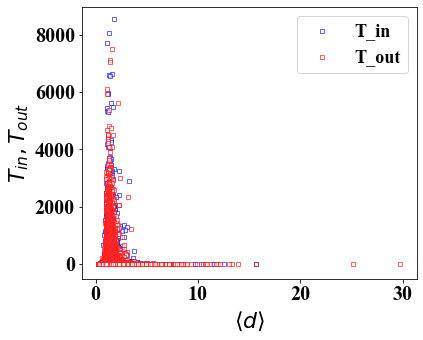

In [21]:
fig= plt.figure(figsize=(6,5))        #一个区域的出和进流量
ax = fig.add_subplot(1,1,1) 
plt.scatter(d_in,T_in,marker = 's',color="w",linewidths=1,s=20,edgecolors='blue',label="T_in",alpha=0.6)
plt.scatter(d_out,T_out,marker = 's',color="w",linewidths=1,s=20,edgecolors='red',label="T_out",alpha=0.6)
#plt.plot( eavd,eloc_num, marker='.',color="red",label="in_Tij",alpha=0.1)
plt.legend(loc="best",prop={'size':18,'family':'Times New Roman'})
#ax.set_yscale("log")
#ax.set_xscale("log")
#plt.xlim(10^0,10^10)
plt.yticks(fontproperties = 'Times New Roman')
plt.xticks(fontproperties = 'Times New Roman') 
ax.set_ylabel("$T_{in},T_{out}$",size=22,family='Times New Roman')  
ax.set_xlabel(r"$\langle d \rangle$",size=22,family='Times New Roman')
plt.tick_params(labelsize=20)
plt.savefig('500m区域出行平均距离与出入流.pdf')

# 加权距离和流量

In [1]:
weid_out=[]
#weiT_out=[]

for temp in ind:
    dr=df1_3[df1_3["sid"]==temp]  #某个区域的所有记录
    length=len(dr)
    a=(dr["eid"].value_counts().index).tolist()   #所有到达地
    weid=[]
    for val in a:
        dr1=dr[dr["eid"]==val]
        b=sum(dr1["distance(m)"].tolist())/1000*(len(dr1)/length)
        weid.append(b)
    weid_out.append(sum(weid)/len(a))

In [ ]:
weid_in=[]
#weiT_out=[]

for temp in ind1:
    dr=df1_3[df1_3["eid"]==temp]
    length=len(dr)
    a=(dr["sid"].value_counts().index).tolist()
    weid=[]
    for val in a:
        dr1=dr[dr["sid"]==val]
        b=sum(dr1["distance(m)"].tolist())/1000*(len(dr1)/length)
        weid.append(b)
    weid_in.append(sum(weid)/len(a))

In [44]:
np.save('weid_in(bj)',weid_in)   #保存数据
np.save('T_in(bj)',T_in)
np.save('weid_out(bj)',weid_out)
np.save('T_out(bj)',T_out)

In [12]:
#weid_in=np.load('weid_in(bj).npy').tolist()
#T_in=np.load('T_in(bj).npy').tolist()
#weid_out=np.load('weid_out(bj).npy').tolist()
#T_out=np.load('T_out(bj).npy').tolist()

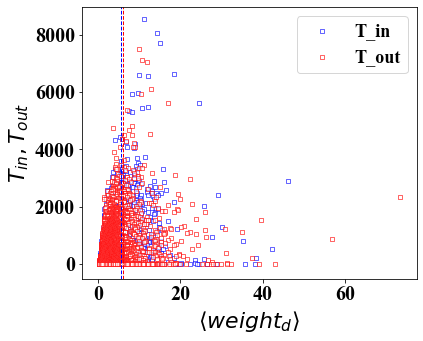

In [13]:
fig= plt.figure(figsize=(6,5))        #一个区域的出和进流量
ax = fig.add_subplot(1,1,1) 
ax.axvline(x=5.5, color='blue', linewidth=1,ls='--')
plt.scatter(weid_in,T_in,marker = 's',color="w",linewidths=1,s=20,edgecolors='blue',label="T_in",alpha=0.6)
ax.axvline(x=6, color='red', linewidth=1,ls='--')
plt.scatter(weid_out,T_out,marker = 's',color="w",linewidths=1,s=20,edgecolors='red',label="T_out",alpha=0.6)
#plt.plot( eavd,eloc_num, marker='.',color="red",label="in_Tij",alpha=0.1)
plt.legend(loc="best",prop={'size':18,'family':'Times New Roman'})
#ax.set_yscale("log")
#ax.set_xscale("log")
#plt.xlim(10^0,10^10)
plt.yticks(fontproperties = 'Times New Roman')
plt.xticks(fontproperties = 'Times New Roman') 
ax.set_ylabel("$T_{in},T_{out}$",size=22,family='Times New Roman')  
ax.set_xlabel(r"$\langle weight_d\rangle$",size=22,family='Times New Roman')
plt.tick_params(labelsize=20)
#plt.savefig('500m区域出行加权平均距离与出入流.pdf')